In [ ]:
!pip install networkx pandas matplotlib -q

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import pickle

In [ ]:
from google.colab import files
uploaded = files.upload()
import zipfile, os
if any(f.endswith(".zip") for f in uploaded.keys()):
    zip_name = [f for f in uploaded.keys() if f.endswith(".zip")][0]
    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall("ds_jobs_data")
    data_dir = "ds_jobs_data"
else:
    data_dir = "."

print(os.listdir(data_dir))

Saving archive (1).zip to archive (1).zip
['job_postings.csv', 'job_summary.csv', 'job_skills.csv']


In [ ]:
postings = pd.read_csv(f"{data_dir}/job_postings.csv")
skills = pd.read_csv(f"{data_dir}/job_skills.csv")

print("job_postings columns:", list(postings.columns))
print("job_skills columns:", list(skills.columns))
postings.head(2)
skills.head(2)

job_postings columns: ['job_link', 'last_processed_time', 'last_status', 'got_summary', 'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type']
job_skills columns: ['job_link', 'job_skills']


,job_link,job_skills
0,https://www.linkedin.com/jobs/view/senior-mach...,"Machine Learning, Programming, Python, Scala, ..."
1,https://www.linkedin.com/jobs/view/principal-s...,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,..."


In [ ]:
JOIN_KEY = "job_link"
JOB_TITLE_COL = "job_title"
SKILLS_COL = "job_skills"
df = postings.merge(skills, on=JOIN_KEY, how="inner")
print(f"{len(df)} jobs after joining")
df[[JOB_TITLE_COL, SKILLS_COL]].head()

12217 jobs after joining


,job_title,job_skills
0,Senior Machine Learning Engineer,"Machine Learning, Programming, Python, Scala, ..."
1,"Principal Software Engineer, ML Accelerators","C++, Python, PyTorch, TensorFlow, MXNet, CUDA,..."
2,Senior ETL Data Warehouse Specialist,"ETL, Data Integration, Data Transformation, Da..."
3,Senior Data Warehouse Developer / Architect,"Data Lakes, Data Bricks, Azure Data Factory Pi..."
4,Lead Data Engineer,"Java, Scala, Python, RDBMS, NoSQL, Redshift, S..."


In [ ]:
SKILL_WHITELIST = {
    "python", "r", "sql", "java", "scala", "c++", "julia",
    "machine learning", "deep learning", "nlp", "computer vision",
    "tensorflow", "pytorch", "keras", "scikit-learn", "mxnet", "cuda",
    "pandas", "numpy", "spark", "hadoop", "hive", "kafka", "airflow",
    "aws", "azure", "gcp", "docker", "kubernetes", "git", "linux",
    "tableau", "power bi", "excel", "matplotlib", "seaborn",
    "statistics", "data visualization", "data analysis", "data engineering",
    "etl", "data warehousing", "big data", "a/b testing", "regression",
    "classification", "clustering", "neural networks", "computer science",
    "mysql", "postgresql", "mongodb", "nosql", "snowflake", "databricks",
    "data modeling", "data mining", "predictive modeling", "time series",
    "communication", "project management", "agile", "leadership",
}

def clean_skills(raw_skill_string):
    if pd.isna(raw_skill_string):
        return []
    parts = [s.strip().lower() for s in str(raw_skill_string).split(",")]
    matched = [s for s in parts if s in SKILL_WHITELIST]
    return list(dict.fromkeys(matched))

df = df.dropna(subset=[JOB_TITLE_COL, SKILLS_COL]).copy()
df["skills_clean"] = df[SKILLS_COL].apply(clean_skills)
df = df[df["skills_clean"].map(len) > 0]
print(f"{len(df)} rows remain after whitelist filtering")
df["skills_clean"].apply(len).describe()

10236 rows remain after whitelist filtering


,skills_clean
count,10236.000000
mean,5.564185
std,4.015515
min,1.000000
25%,2.000000
50%,5.000000
75%,8.000000
max,31.000000


In [ ]:
N_JOBS_TO_SAMPLE = 30
RANDOM_SEED = 42

df_sample = df.sample(n=min(N_JOBS_TO_SAMPLE, len(df)), random_state=RANDOM_SEED)
df_sample = df_sample.reset_index(drop=True)
df_sample["job_id"] = [f"job_{i}" for i in range(len(df_sample))]
df_sample[[JOB_TITLE_COL, "skills_clean"]].head()

,job_title,skills_clean
0,"Principal Associate, Data Loss Prevention (DLP...","[agile, aws]"
1,Marketing Data & Analytics Product Owner - Sen...,"[communication, leadership, sql, python, r, ta..."
2,Lead Data Platform Engineer,"[data modeling, data warehousing, etl, machine..."
3,Canvas Consultant (Member Service Specialist) ...,"[leadership, communication]"
4,"Lead Software Engineer, Full Stack (Enterprise...","[python, postgresql, aws, kubernetes, docker, ..."


In [ ]:
print(df_sample[df_sample[JOB_TITLE_COL].str.contains("0644", na=False)][[JOB_TITLE_COL, SKILLS_COL]])

                     job_title  \
8  0644 - Développeur Big Data   

                                          job_skills  
8  Big Data, Data Engineering, DataOps, BI, Cloud...  


In [ ]:
G = nx.Graph()

for _, row in df_sample.iterrows():
    G.add_node(row["job_id"], bipartite="job", title=row[JOB_TITLE_COL])

all_skills = [s for skills_list in df_sample["skills_clean"] for s in skills_list]
skill_freq = pd.Series(all_skills).value_counts()
max_freq = skill_freq.max()

for _, row in df_sample.iterrows():
    for skill in row["skills_clean"]:
        if skill not in G:
            G.add_node(skill, bipartite="skill")
        weight = round(max_freq / skill_freq[skill], 2)
        G.add_edge(row["job_id"], skill, weight=weight)

n_jobs = sum(1 for _, d in G.nodes(data=True) if d.get("bipartite") == "job")
n_skills = sum(1 for _, d in G.nodes(data=True) if d.get("bipartite") == "skill")
print(f"Graph built: {n_jobs} jobs, {n_skills} skills, {G.number_of_edges()} edges")


Graph built: 30 jobs, 50 skills, 245 edges


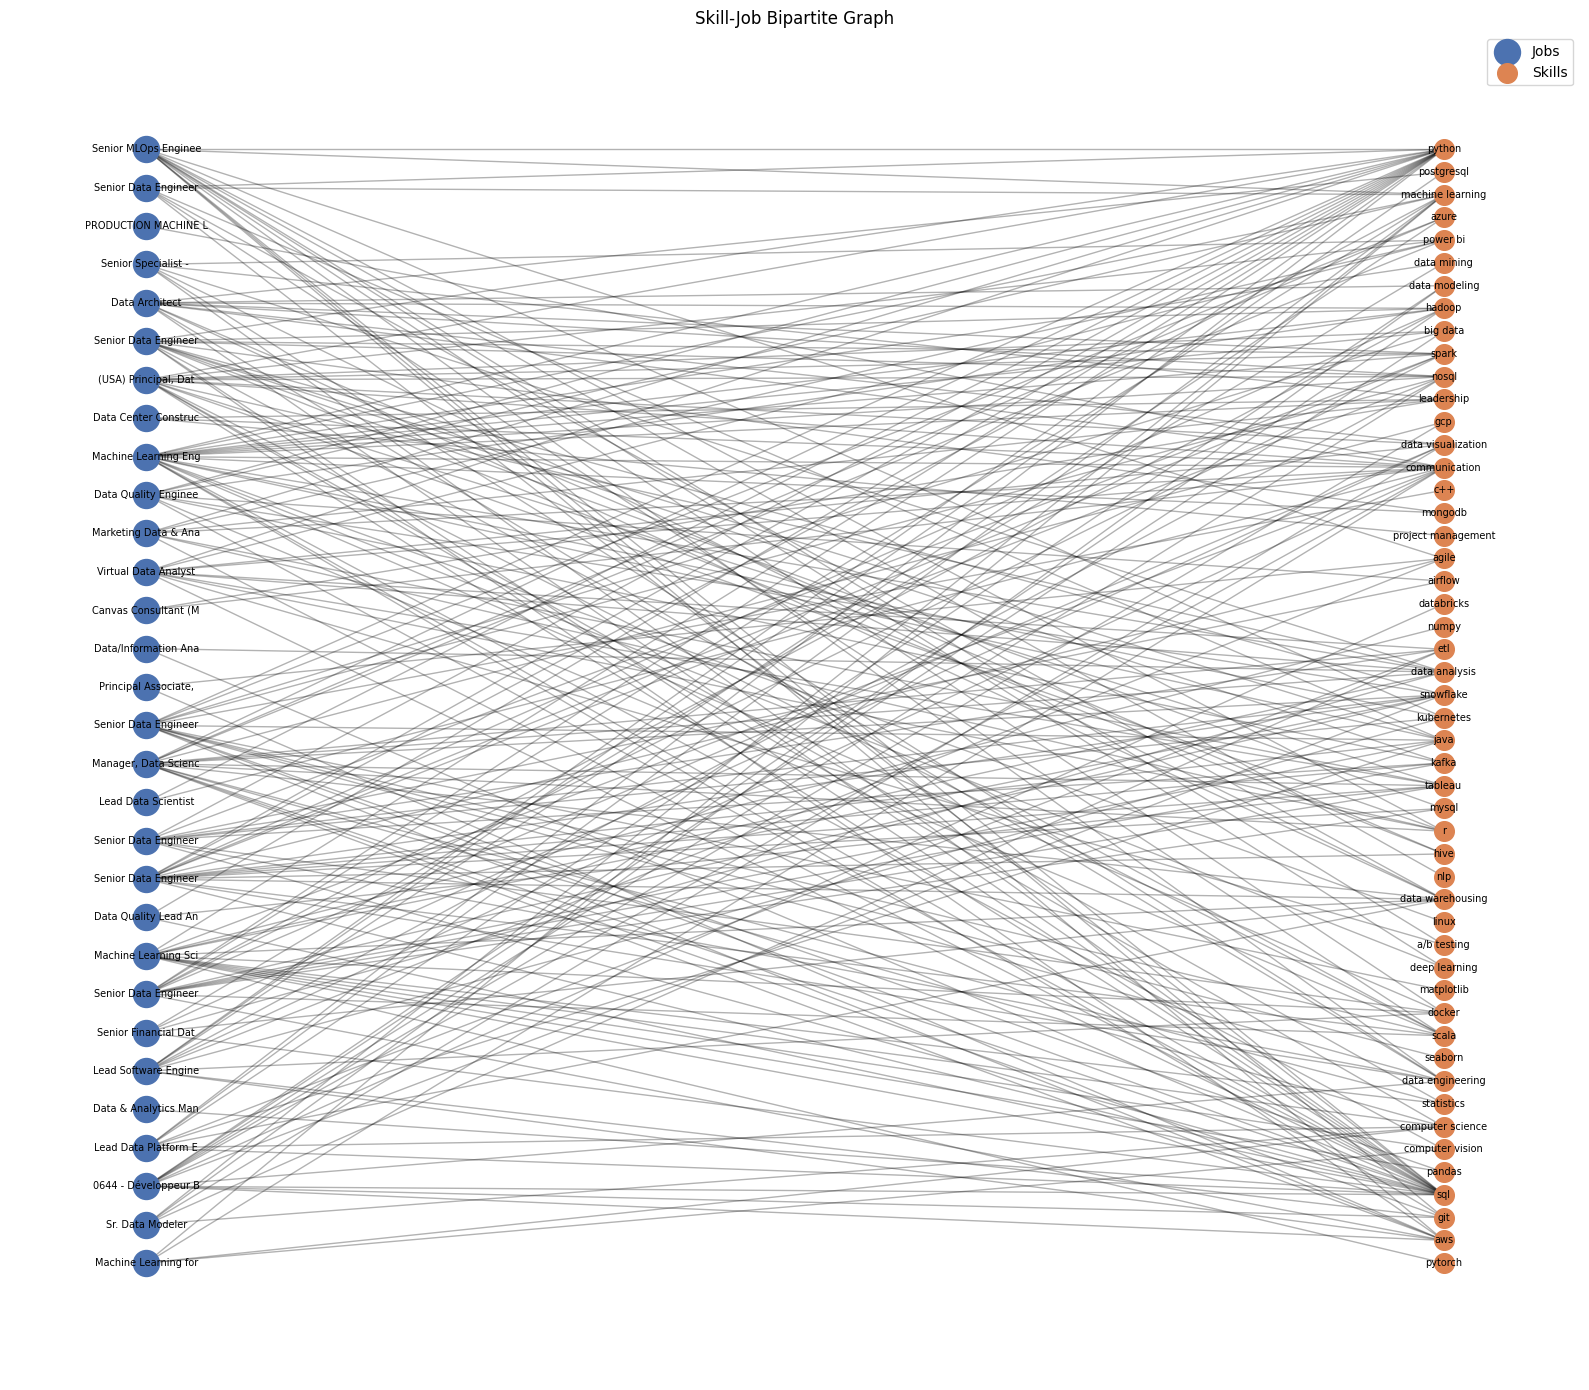

In [ ]:
job_nodes = [n for n, d in G.nodes(data=True) if d.get("bipartite") == "job"]
skill_nodes = [n for n, d in G.nodes(data=True) if d.get("bipartite") == "skill"]
pos = nx.bipartite_layout(G, job_nodes)

plt.figure(figsize=(16, 14))
nx.draw_networkx_nodes(G, pos, nodelist=job_nodes, node_color="#4C72B0", node_size=350, label="Jobs")
nx.draw_networkx_nodes(G, pos, nodelist=skill_nodes, node_color="#DD8452", node_size=200, label="Skills")
nx.draw_networkx_edges(G, pos, alpha=0.3)

job_labels = dict(zip(df_sample["job_id"], df_sample[JOB_TITLE_COL].str.slice(0, 20)))
skill_labels = {s: s for s in skill_nodes}
nx.draw_networkx_labels(G, pos, labels={**job_labels, **skill_labels}, font_size=7)

plt.legend(scatterpoints=1)
plt.title("Skill-Job Bipartite Graph")
plt.axis("off")
plt.tight_layout()
plt.savefig("skill_job_bipartite_graph.png", dpi=150)
plt.show()

In [ ]:
edges = [{"job_or_skill_1": u, "job_or_skill_2": v, "weight": d["weight"]} for u, v, d in G.edges(data=True)]
pd.DataFrame(edges).to_csv("skill_job_edges.csv", index=False)

with open("skill_job_graph.gpickle", "wb") as f:
    pickle.dump(G, f)

files.download("skill_job_edges.csv")
files.download("skill_job_graph.gpickle")
files.download("skill_job_bipartite_graph.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

print("Both libraries imported successfully!")

NumPy version: 2.1.3
Pandas version: 2.2.3
Both libraries imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import zipfile

ZIP_PATH = "/content/SkillJobRec-main.zip"

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Project extracted successfully!")

Project extracted successfully!


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "skill_job_graph.gpickle":
            print(os.path.join(root, file))

/content/SkillJobRec-main/data/skill_job_graph.gpickle


In [ ]:
# ==========================================
# STEP 2: LOAD AND VERIFY THE GRAPH
# ==========================================

import os
import pickle
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# Path to your saved graph
GRAPH_PATH = "/content/SkillJobRec-main/data/skill_job_graph.gpickle"

# Load graph
with open(GRAPH_PATH, "rb") as f:
    base_graph = pickle.load(f)

# Print graph information
print("Graph loaded successfully!")
print("Number of nodes:", base_graph.number_of_nodes())
print("Number of edges:", base_graph.number_of_edges())

# Separate jobs and skills
job_nodes = [
    node for node, attrs in base_graph.nodes(data=True)
    if attrs.get("bipartite") == "job"
]

skill_nodes = [
    node for node, attrs in base_graph.nodes(data=True)
    if attrs.get("bipartite") == "skill"
]

print("Job nodes:", len(job_nodes))
print("Skill nodes:", len(skill_nodes))

# Verify Person 1's numbers
assert base_graph.number_of_nodes() == 80
assert base_graph.number_of_edges() == 245
assert len(job_nodes) == 30
assert len(skill_nodes) == 50

print("\nAll graph counts match Person 1's numbers!")

Graph loaded successfully!
Number of nodes: 80
Number of edges: 245
Job nodes: 30
Skill nodes: 50

All graph counts match Person 1's numbers!


In [ ]:
# Display first 20 skill nodes
print("SKILLS IN GRAPH:\n")

for skill in skill_nodes[:20]:
    print(skill)

SKILLS IN GRAPH:

agile
aws
communication
leadership
sql
python
r
tableau
power bi
data modeling
data warehousing
etl
machine learning
java
computer science
postgresql
kubernetes
docker
nosql
git


In [ ]:
candidate_profiles = {
    "Data Scientist": [
        "python",
        "sql",
        "r",
        "pandas",
        "machine learning",
        "statistics",
        "data visualization"
    ],

    "Data Engineer": [
        "python",
        "sql",
        "aws",
        "spark",
        "etl",
        "data modeling",
        "docker"
    ],

    "Full Stack Engineer": [
        "python",
        "sql",
        "javascript",
        "react",
        "node.js",
        "docker",
        "git"
    ]
}

for candidate, skills in candidate_profiles.items():
    print(candidate)
    print(skills)
    print()

Data Scientist
['python', 'sql', 'r', 'pandas', 'machine learning', 'statistics', 'data visualization']

Data Engineer
['python', 'sql', 'aws', 'spark', 'etl', 'data modeling', 'docker']

Full Stack Engineer
['python', 'sql', 'javascript', 'react', 'node.js', 'docker', 'git']



In [ ]:
# ==========================================
# STEP 8: MATCH CANDIDATE SKILLS TO GRAPH
# ==========================================

# Candidate profiles
candidate_profiles = {
    "Data Scientist": [
        "python",
        "sql",
        "r",
        "pandas",
        "machine learning",
        "statistics",
        "data visualization"
    ],

    "Data Engineer": [
        "python",
        "sql",
        "aws",
        "spark",
        "etl",
        "data modeling",
        "docker"
    ],

    "Full Stack Engineer": [
        "python",
        "sql",
        "javascript",
        "react",
        "node.js",
        "docker",
        "git"
    ]
}

# Convert graph skills into a set
available_skills = set(skill_nodes)

# Match each candidate's skills
matched_profiles = {}

for candidate, skills in candidate_profiles.items():

    matched_skills = [
        skill for skill in skills
        if skill in available_skills
    ]

    missing_skills = [
        skill for skill in skills
        if skill not in available_skills
    ]

    matched_profiles[candidate] = matched_skills

    print("=" * 50)
    print("Candidate:", candidate)
    print("Matched skills:", matched_skills)
    print("Missing skills:", missing_skills)
    print("Matched count:", len(matched_skills))

Candidate: Data Scientist
Matched skills: ['python', 'sql', 'r', 'pandas', 'machine learning', 'statistics', 'data visualization']
Missing skills: []
Matched count: 7
Candidate: Data Engineer
Matched skills: ['python', 'sql', 'aws', 'spark', 'etl', 'data modeling', 'docker']
Missing skills: []
Matched count: 7
Candidate: Full Stack Engineer
Matched skills: ['python', 'sql', 'docker', 'git']
Missing skills: ['javascript', 'react', 'node.js']
Matched count: 4


In [ ]:
# ==========================================
# STEP 9: CREATE TEMPORARY CANDIDATE GRAPH
# ==========================================

def create_candidate_graph(base_graph, candidate_name, candidate_skills):
    """
    Create a copy of the original graph and add
    one temporary candidate node.

    The original base_graph remains unchanged.
    """

    # Copy original graph
    G = base_graph.copy()

    # Candidate node name
    candidate_node = f"Candidate: {candidate_name}"

    # Add candidate node
    G.add_node(
        candidate_node,
        bipartite="candidate",
        candidate_name=candidate_name
    )

    # Connect candidate to matched skills
    for skill in candidate_skills:

        G.add_edge(
            candidate_node,
            skill,
            weight=1.0
        )

    return G, candidate_node

In [ ]:
# ==========================================
# STEP 10: TEST CANDIDATE GRAPH
# ==========================================

candidate_name = "Data Scientist"

candidate_skills = matched_profiles[candidate_name]

G_test, candidate_node = create_candidate_graph(
    base_graph,
    candidate_name,
    candidate_skills
)

print("Candidate graph created!")
print("Candidate node:", candidate_node)
print("Candidate skills:", candidate_skills)

print("\nOriginal graph:")
print("Nodes:", base_graph.number_of_nodes())
print("Edges:", base_graph.number_of_edges())

print("\nCandidate graph:")
print("Nodes:", G_test.number_of_nodes())
print("Edges:", G_test.number_of_edges())

Candidate graph created!
Candidate node: Candidate: Data Scientist
Candidate skills: ['python', 'sql', 'r', 'pandas', 'machine learning', 'statistics', 'data visualization']

Original graph:
Nodes: 80
Edges: 245

Candidate graph:
Nodes: 81
Edges: 252


In [ ]:
# ==========================================
# STEP 11: PERSONALIZED PAGERANK
# ==========================================

def run_personalized_pagerank(
    base_graph,
    candidate_name,
    candidate_skills
):
    """
    Create a temporary candidate graph and run
    Personalized PageRank.

    The original graph is never modified.
    """

    # Create a copy of the original graph
    G = base_graph.copy()

    # Unique candidate node
    candidate_node = f"Candidate: {candidate_name}"

    # Add candidate node
    G.add_node(
        candidate_node,
        bipartite="candidate",
        candidate_name=candidate_name
    )

    # Connect candidate to their skills
    for skill in candidate_skills:

        G.add_edge(
            candidate_node,
            skill,
            weight=1.0
        )

    # Personalization vector
    personalization = {
        candidate_node: 1.0
    }

    # Run Personalized PageRank
    pagerank_scores = nx.pagerank(
        G,
        alpha=0.85,
        personalization=personalization,
        weight="weight"
    )

    return G, candidate_node, pagerank_scores

In [ ]:
# ==========================================
# STEP 12: TEST PAGERANK
# ==========================================

candidate_name = "Data Scientist"

candidate_skills = matched_profiles[candidate_name]

G_ds, candidate_node_ds, scores_ds = run_personalized_pagerank(
    base_graph,
    candidate_name,
    candidate_skills
)

print("Personalized PageRank completed!")

print("Candidate:", candidate_node_ds)

print("Number of scored nodes:", len(scores_ds))

print("Original graph nodes:", base_graph.number_of_nodes())

print("Candidate graph nodes:", G_ds.number_of_nodes())

print("\nTop 10 nodes by PageRank:")

top_nodes = sorted(
    scores_ds.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

for node, score in top_nodes:
    print(node, "->", round(score, 6))

Personalized PageRank completed!
Candidate: Candidate: Data Scientist
Number of scored nodes: 81
Original graph nodes: 80
Candidate graph nodes: 81

Top 10 nodes by PageRank:
Candidate: Data Scientist -> 0.157348
job_28 -> 0.042784
job_17 -> 0.035518
statistics -> 0.028296
r -> 0.027865
job_14 -> 0.027765
data visualization -> 0.027476
sql -> 0.027015
job_20 -> 0.0268
job_13 -> 0.02676


In [ ]:
# ==========================================
# STEP 13: EXTRACT JOB RECOMMENDATIONS
# ==========================================

def get_job_recommendations(
    graph,
    pagerank_scores,
    top_n=10
):
    """
    Filter PageRank scores to job nodes only
    and return ranked recommendations.
    """

    job_scores = []

    for node, score in pagerank_scores.items():

        # Only select job nodes
        if graph.nodes[node].get("bipartite") == "job":

            job_scores.append({
                "job": node,
                "score": score
            })

    # Sort by PageRank score
    job_scores = sorted(
        job_scores,
        key=lambda x: x["score"],
        reverse=True
    )

    # Take top N
    return job_scores[:top_n]

In [ ]:
# ==========================================
# STEP 13.1: DATA SCIENTIST RECOMMENDATIONS
# ==========================================

recommendations_ds = get_job_recommendations(
    G_ds,
    scores_ds,
    top_n=10
)

print("Top job recommendations for Data Scientist:\n")

for rank, item in enumerate(recommendations_ds, start=1):

    print(
        rank,
        "|",
        item["job"],
        "| Score:",
        round(item["score"], 6)
    )

Top job recommendations for Data Scientist:

1 | job_28 | Score: 0.042784
2 | job_17 | Score: 0.035518
3 | job_14 | Score: 0.027765
4 | job_20 | Score: 0.0268
5 | job_13 | Score: 0.02676
6 | job_29 | Score: 0.024889
7 | job_12 | Score: 0.018952
8 | job_5 | Score: 0.016653
9 | job_11 | Score: 0.015308
10 | job_24 | Score: 0.014505


In [ ]:
# ==========================================
# STEP 14: RUN ALL CANDIDATES
# ==========================================

all_recommendations = {}

for candidate_name, candidate_skills in matched_profiles.items():

    print("=" * 60)
    print("Candidate:", candidate_name)

    # Run PageRank
    G_candidate, candidate_node, scores = run_personalized_pagerank(
        base_graph,
        candidate_name,
        candidate_skills
    )

    # Extract top jobs
    recommendations = get_job_recommendations(
        G_candidate,
        scores,
        top_n=10
    )

    all_recommendations[candidate_name] = recommendations

    # Print results
    for rank, item in enumerate(recommendations, start=1):

        print(
            rank,
            "|",
            item["job"],
            "| Score:",
            round(item["score"], 6)
        )

Candidate: Data Scientist
1 | job_28 | Score: 0.042784
2 | job_17 | Score: 0.035518
3 | job_14 | Score: 0.027765
4 | job_20 | Score: 0.0268
5 | job_13 | Score: 0.02676
6 | job_29 | Score: 0.024889
7 | job_12 | Score: 0.018952
8 | job_5 | Score: 0.016653
9 | job_11 | Score: 0.015308
10 | job_24 | Score: 0.014505
Candidate: Data Engineer
1 | job_13 | Score: 0.03175
2 | job_29 | Score: 0.026882
3 | job_28 | Score: 0.023526
4 | job_14 | Score: 0.023112
5 | job_17 | Score: 0.022957
6 | job_24 | Score: 0.022934
7 | job_26 | Score: 0.022246
8 | job_15 | Score: 0.019859
9 | job_5 | Score: 0.019405
10 | job_2 | Score: 0.01922
Candidate: Full Stack Engineer
1 | job_13 | Score: 0.042856
2 | job_29 | Score: 0.038446
3 | job_28 | Score: 0.029849
4 | job_4 | Score: 0.02609
5 | job_14 | Score: 0.025278
6 | job_8 | Score: 0.022803
7 | job_17 | Score: 0.02273
8 | job_26 | Score: 0.020025
9 | job_5 | Score: 0.016457
10 | job_15 | Score: 0.015296


In [ ]:
# ==========================================
# STEP 15: SAVE ALL RECOMMENDATIONS TO CSV
# ==========================================

import os
import pandas as pd

# Create output directory
DATA_DIR = "/content/SkillJobRec-main/data"
os.makedirs(DATA_DIR, exist_ok=True)

# Store all results
results = []

for candidate_name, recommendations in all_recommendations.items():

    for rank, item in enumerate(recommendations, start=1):

        results.append({
            "candidate": candidate_name,
            "job": item["job"],
            "score": item["score"],
            "rank": rank
        })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Save CSV
RESULTS_PATH = os.path.join(
    DATA_DIR,
    "job_recommendations.csv"
)

results_df.to_csv(
    RESULTS_PATH,
    index=False
)

print("Recommendations saved successfully!")
print("File path:", RESULTS_PATH)

print("\nTotal recommendation rows:", len(results_df))

print("\nFirst 10 rows:")
display(results_df.head(10))

Recommendations saved successfully!
File path: /content/SkillJobRec-main/data/job_recommendations.csv

Total recommendation rows: 30

First 10 rows:


,candidate,job,score,rank
0,Data Scientist,job_28,0.042784,1
1,Data Scientist,job_17,0.035518,2
2,Data Scientist,job_14,0.027765,3
3,Data Scientist,job_20,0.026800,4
4,Data Scientist,job_13,0.026760,5
5,Data Scientist,job_29,0.024889,6
6,Data Scientist,job_12,0.018952,7
7,Data Scientist,job_5,0.016653,8
8,Data Scientist,job_11,0.015308,9
9,Data Scientist,job_24,0.014505,10


In [ ]:
# ==========================================
# STEP 16: LOAD AND VERIFY RESULTS CSV
# ==========================================

loaded_results = pd.read_csv(RESULTS_PATH)

print("CSV loaded successfully!")

print("Shape:", loaded_results.shape)

print("\nColumns:")
print(loaded_results.columns.tolist())

print("\nCandidates:")
print(loaded_results["candidate"].unique())

print("\nRecommendation counts:")
print(loaded_results.groupby("candidate").size())

print("\nTop recommendations:")
display(
    loaded_results[
        loaded_results["rank"] == 1
    ]
)

CSV loaded successfully!
Shape: (30, 4)

Columns:
['candidate', 'job', 'score', 'rank']

Candidates:
['Data Scientist' 'Data Engineer' 'Full Stack Engineer']

Recommendation counts:
candidate
Data Engineer          10
Data Scientist         10
Full Stack Engineer    10
dtype: int64

Top recommendations:


,candidate,job,score,rank
0,Data Scientist,job_28,0.042784,1
10,Data Engineer,job_13,0.031750,1
20,Full Stack Engineer,job_13,0.042856,1


In [ ]:
# ==========================================
# STEP 17: TOP 5 COMPARISON TABLE
# ==========================================

top_5 = loaded_results[
    loaded_results["rank"] <= 5
].copy()

comparison_table = top_5.pivot(
    index="rank",
    columns="candidate",
    values="job"
)

print("Top 5 Job Recommendations by Candidate")

display(comparison_table)

Top 5 Job Recommendations by Candidate


candidate,Data Engineer,Data Scientist,Full Stack Engineer
rank,,,
1,job_13,job_28,job_13
2,job_29,job_17,job_29
3,job_28,job_14,job_28
4,job_14,job_20,job_4
5,job_17,job_13,job_14


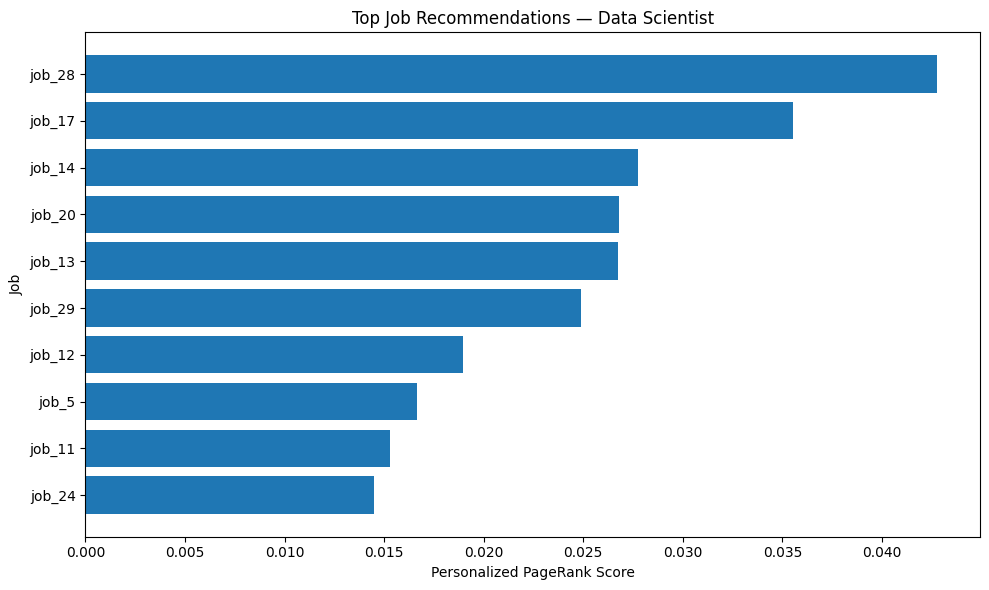

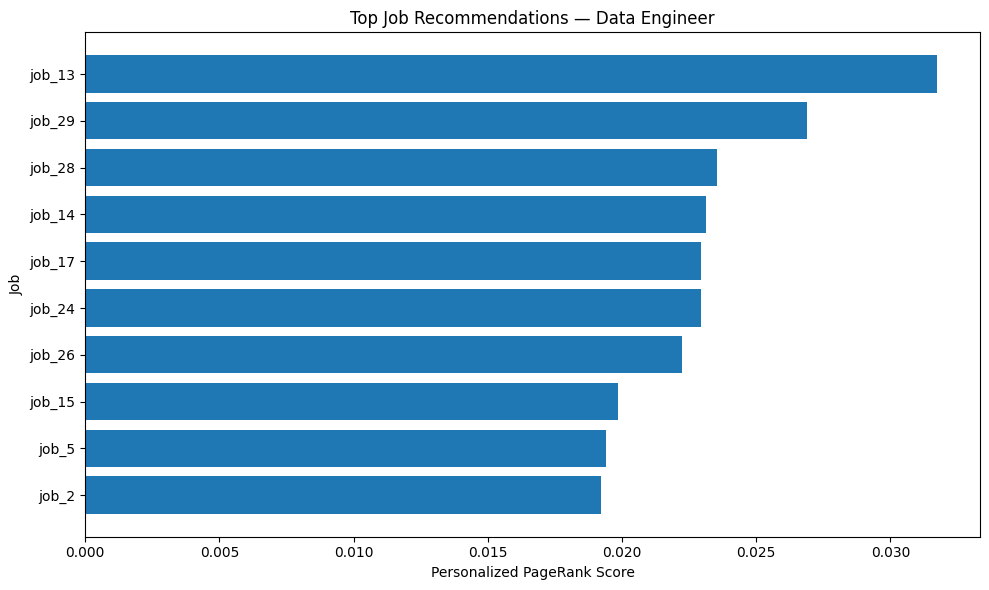

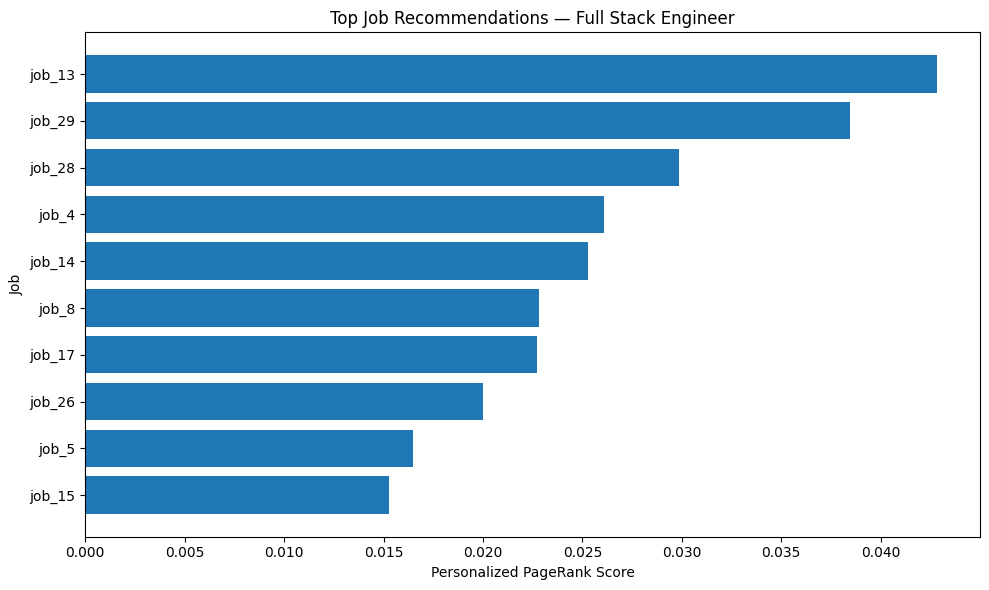

In [ ]:
# ==========================================
# STEP 18: VISUALIZE JOB RECOMMENDATIONS
# ==========================================

import matplotlib.pyplot as plt

candidates = loaded_results["candidate"].unique()

for candidate in candidates:

    candidate_data = loaded_results[
        loaded_results["candidate"] == candidate
    ].sort_values("rank")

    plt.figure(figsize=(10, 6))

    plt.barh(
        candidate_data["job"],
        candidate_data["score"]
    )

    plt.gca().invert_yaxis()

    plt.xlabel("Personalized PageRank Score")
    plt.ylabel("Job")
    plt.title(
        f"Top Job Recommendations — {candidate}"
    )

    plt.tight_layout()

    plt.show()

In [ ]:
# ==========================================
# STEP 19: FINAL GRAPH VISUALIZATION
# ==========================================

import os
import matplotlib.pyplot as plt
import networkx as nx

# Create figures folder
FIGURES_DIR = "/content/SkillJobRec-main/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)


def visualize_candidate_graph(
    base_graph,
    candidate_name,
    candidate_skills,
    recommendations,
    top_n=5
):
    """
    Visualize a candidate's skills and
    top recommended jobs on the base graph.
    """

    # Create a temporary graph
    G = base_graph.copy()

    # Candidate node
    candidate_node = f"Candidate: {candidate_name}"

    # Add candidate
    G.add_node(
        candidate_node,
        bipartite="candidate",
        candidate_name=candidate_name
    )

    # Connect candidate to skills
    for skill in candidate_skills:
        G.add_edge(
            candidate_node,
            skill,
            weight=1.0
        )

    # Get top jobs
    top_jobs = [
        item["job"]
        for item in recommendations[:top_n]
    ]

    # Layout
    pos = nx.spring_layout(
        G,
        seed=42,
        k=0.8
    )

    # Node colors
    node_colors = []

    for node in G.nodes():

        if node == candidate_node:
            node_colors.append("red")

        elif node in candidate_skills:
            node_colors.append("orange")

        elif node in top_jobs:
            node_colors.append("green")

        else:
            node_colors.append("lightgray")

    # Node sizes
    node_sizes = []

    for node in G.nodes():

        if node == candidate_node:
            node_sizes.append(1800)

        elif node in candidate_skills:
            node_sizes.append(700)

        elif node in top_jobs:
            node_sizes.append(1200)

        else:
            node_sizes.append(300)

    # Plot
    plt.figure(figsize=(18, 12))

    nx.draw_networkx_edges(
        G,
        pos,
        alpha=0.25,
        width=0.8
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        node_size=node_sizes,
        alpha=0.9
    )

    # Labels
    labels = {}

    # Candidate label
    labels[candidate_node] = candidate_name

    # Skill labels
    for skill in candidate_skills:
        labels[skill] = skill

    # Job labels
    for job in top_jobs:
        labels[job] = job

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=9,
        font_weight="bold"
    )

    plt.title(
        f"Skill-Job Bipartite Graph — {candidate_name}",
        fontsize=16
    )

    # Legend
    from matplotlib.patches import Patch

    legend_elements = [
        Patch(
            facecolor="red",
            label="Candidate"
        ),
        Patch(
            facecolor="orange",
            label="Candidate Skills"
        ),
        Patch(
            facecolor="green",
            label="Top Recommended Jobs"
        ),
        Patch(
            facecolor="lightgray",
            label="Other Nodes"
        )
    ]

    plt.legend(
        handles=legend_elements,
        loc="upper right"
    )

    plt.axis("off")
    plt.tight_layout()

    # Save figure
    filename = (
        candidate_name.lower()
        .replace(" ", "_")
        + "_final_graph.png"
    )

    filepath = os.path.join(
        FIGURES_DIR,
        filename
    )

    plt.savefig(
        filepath,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", filepath)

Generating graph for: Data Scientist


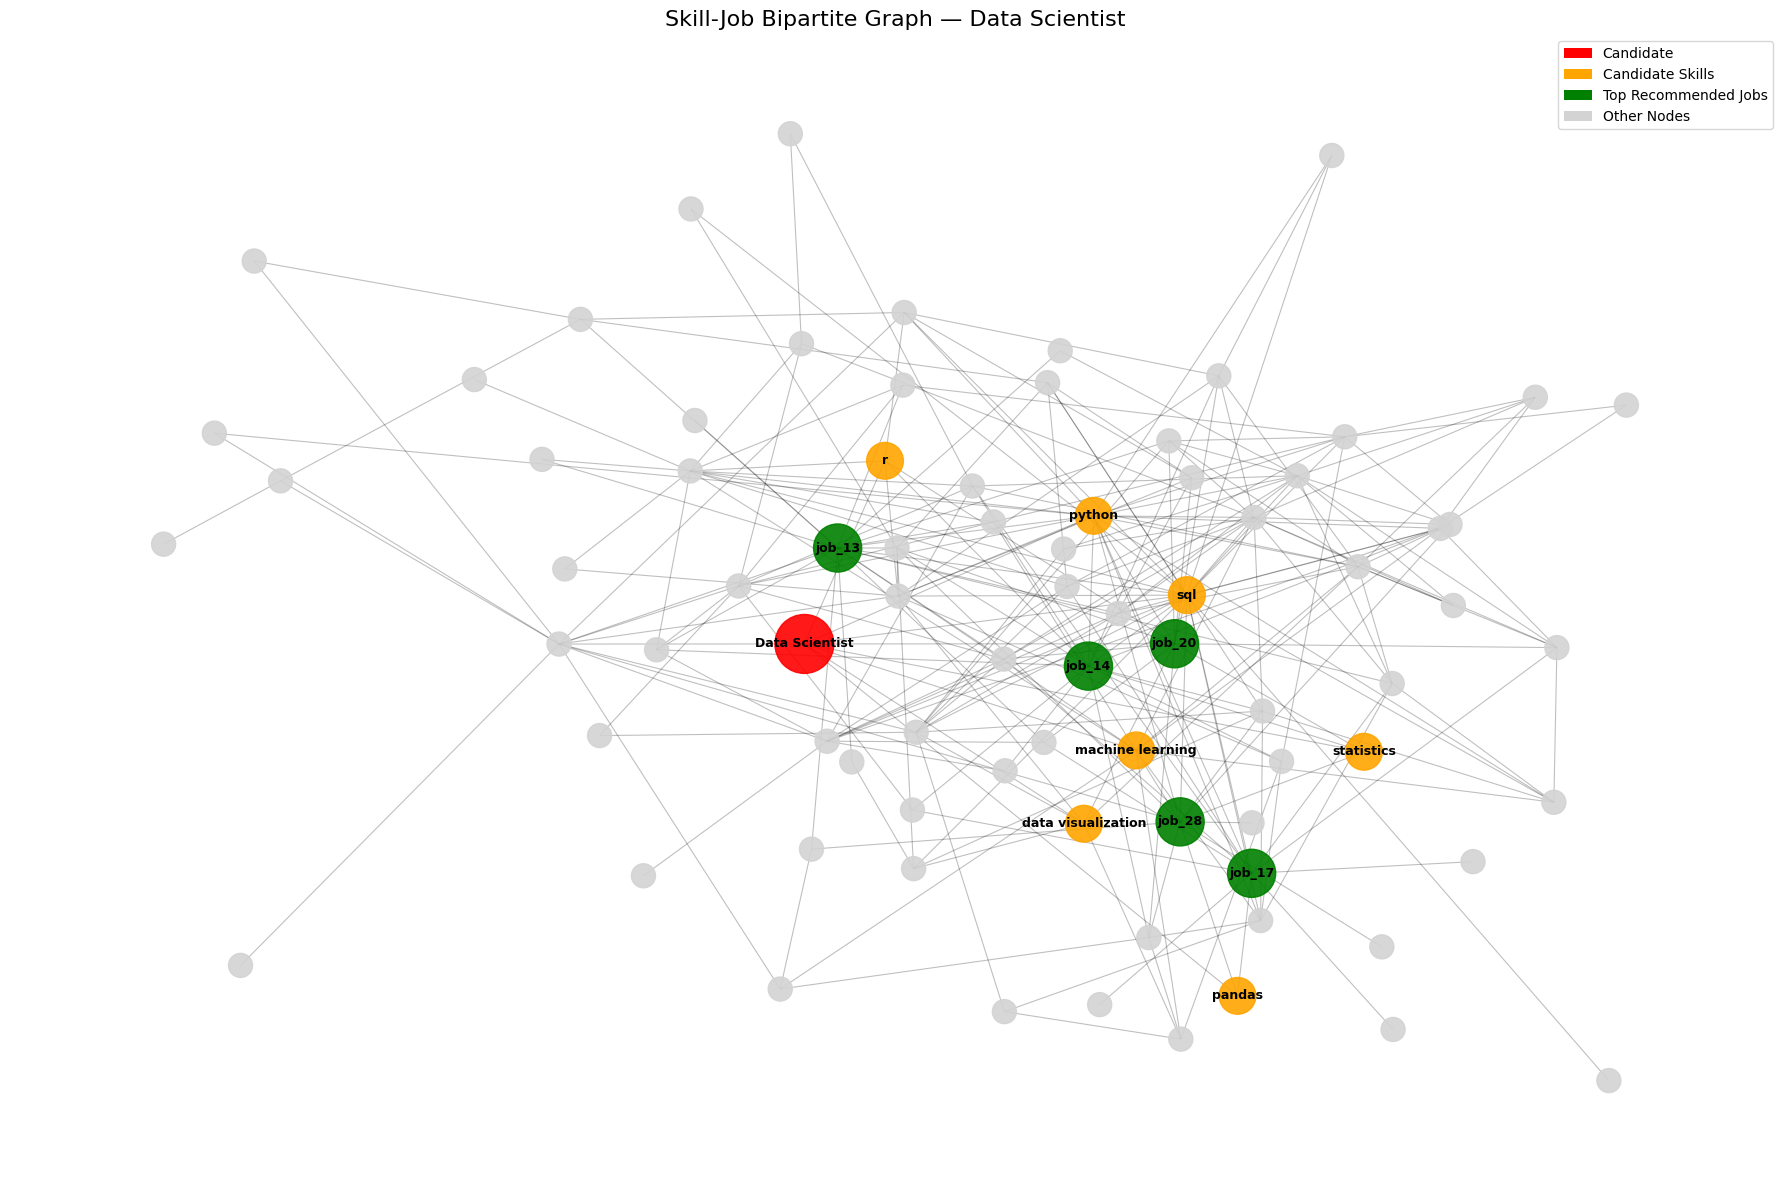

Saved: /content/SkillJobRec-main/figures/data_scientist_final_graph.png
Generating graph for: Data Engineer


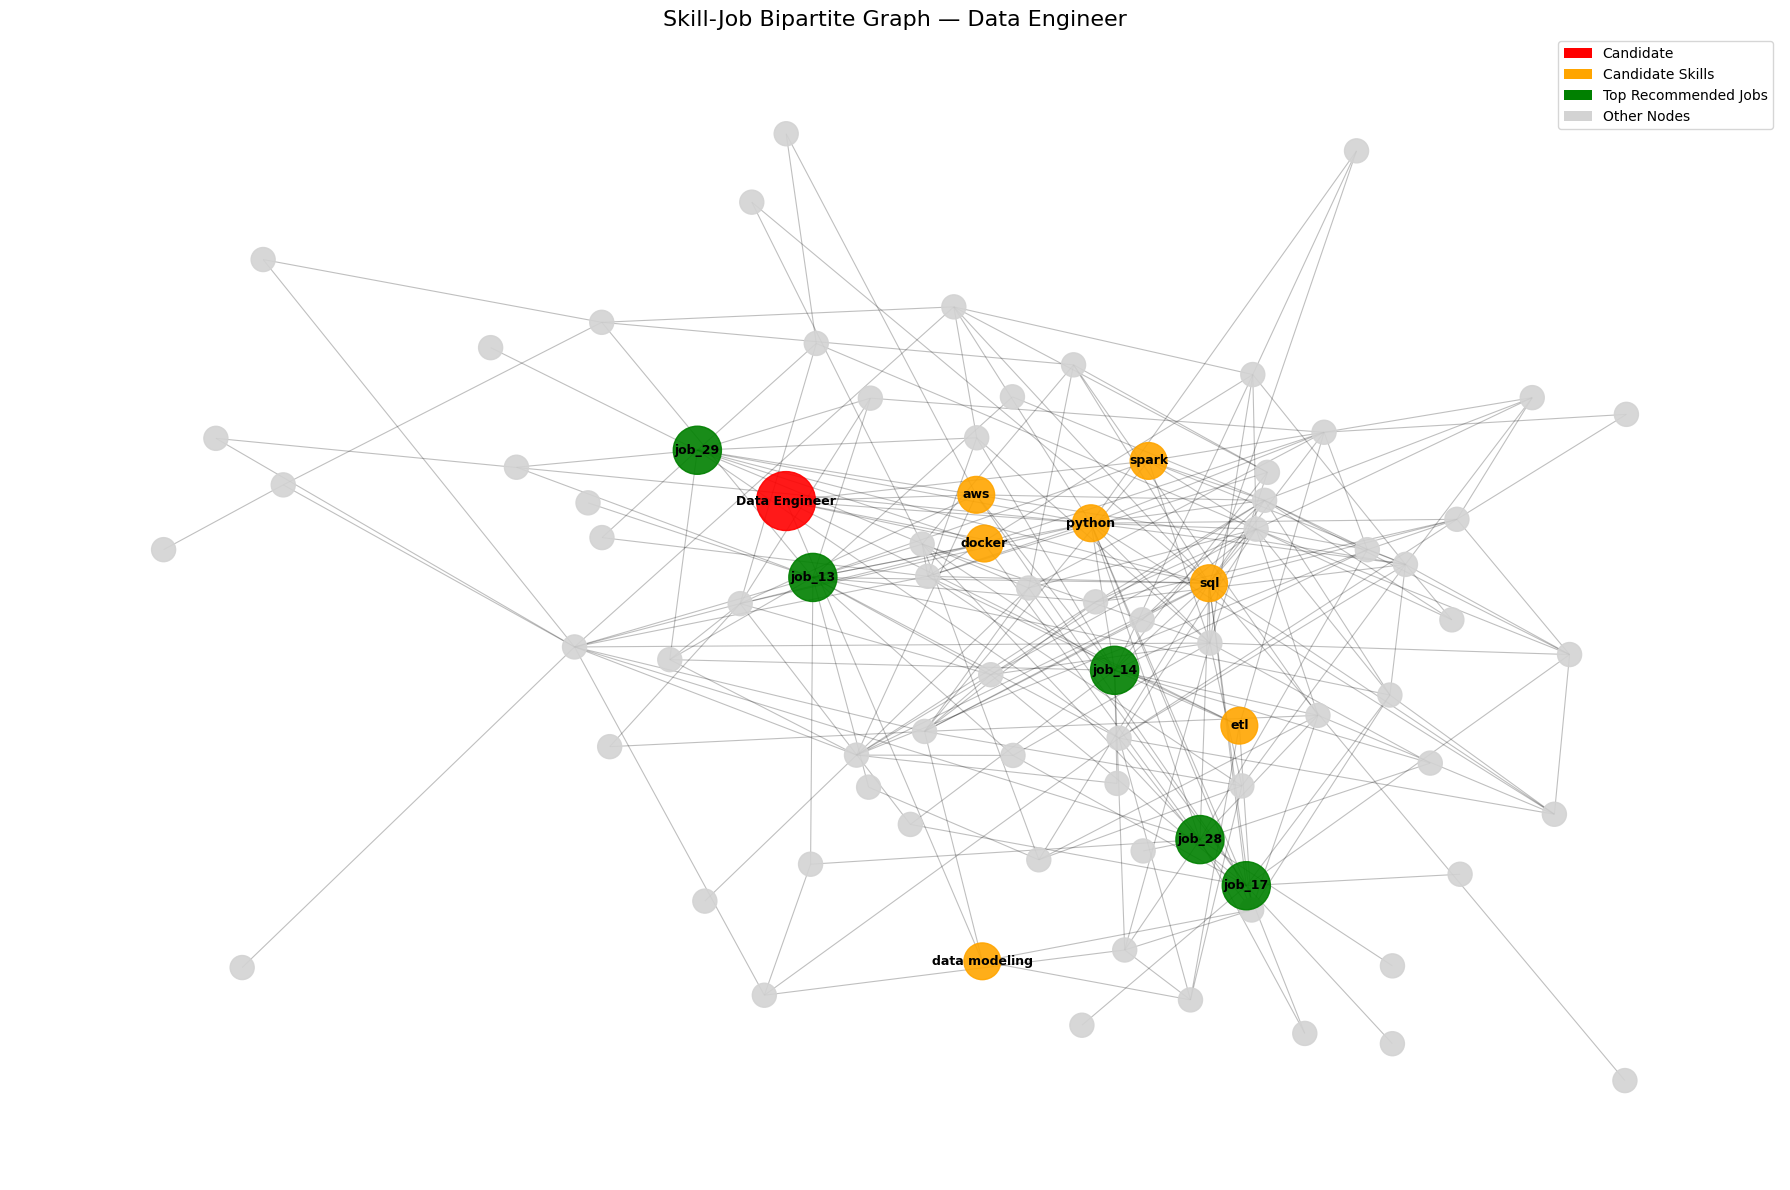

Saved: /content/SkillJobRec-main/figures/data_engineer_final_graph.png
Generating graph for: Full Stack Engineer


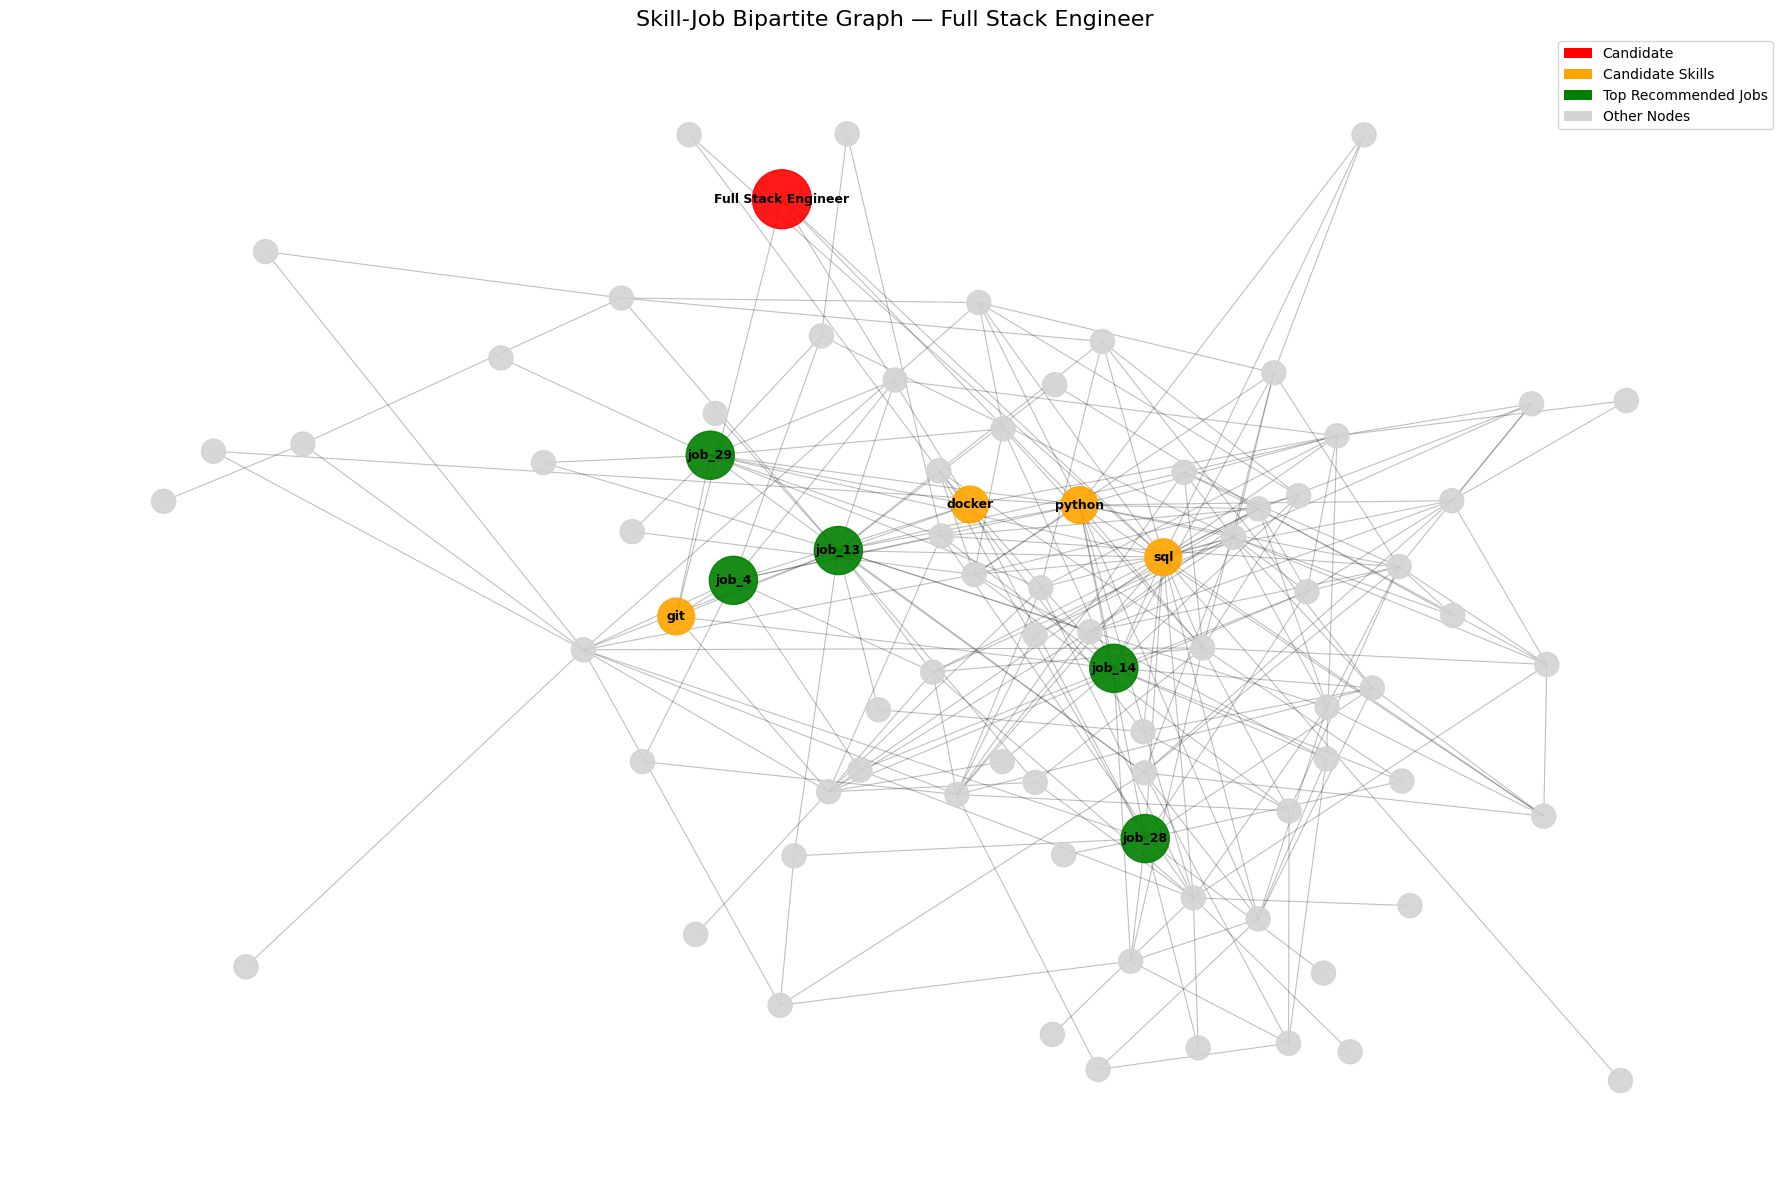

Saved: /content/SkillJobRec-main/figures/full_stack_engineer_final_graph.png


In [ ]:
# ==========================================
# STEP 20: GENERATE ALL FINAL GRAPHS
# ==========================================

for candidate_name, recommendations in all_recommendations.items():

    print("=" * 60)
    print("Generating graph for:", candidate_name)

    candidate_skills = matched_profiles[candidate_name]

    visualize_candidate_graph(
        base_graph=base_graph,
        candidate_name=candidate_name,
        candidate_skills=candidate_skills,
        recommendations=recommendations,
        top_n=5
    )

In [ ]:
# ==========================================
# STEP 21: FINAL ANALYSIS SUMMARY
# ==========================================

summary_rows = []

for candidate_name, recommendations in all_recommendations.items():

    top_5 = recommendations[:5]

    best_job = top_5[0]["job"]
    best_score = top_5[0]["score"]

    avg_top5_score = sum(
        item["score"] for item in top_5
    ) / len(top_5)

    summary_rows.append({
        "candidate": candidate_name,
        "best_job": best_job,
        "best_score": best_score,
        "average_top5_score": avg_top5_score
    })

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

,candidate,best_job,best_score,average_top5_score
0,Data Scientist,job_28,0.042784,0.031926
1,Data Engineer,job_13,0.031750,0.025645
2,Full Stack Engineer,job_13,0.042856,0.032504


In [ ]:
# ==========================================
# STEP 22: RECOMMENDATION OVERLAP
# ==========================================

# Top 5 jobs per candidate
top5_jobs = {}

for candidate_name, recommendations in all_recommendations.items():

    top5_jobs[candidate_name] = set(
        item["job"]
        for item in recommendations[:5]
    )

# Compare candidates
candidate_names = list(top5_jobs.keys())

for i in range(len(candidate_names)):

    for j in range(i + 1, len(candidate_names)):

        c1 = candidate_names[i]
        c2 = candidate_names[j]

        common_jobs = (
            top5_jobs[c1]
            .intersection(top5_jobs[c2])
        )

        print("=" * 50)
        print(c1, "vs", c2)
        print("Common top 5 jobs:", common_jobs)
        print("Number of common jobs:", len(common_jobs))

Data Scientist vs Data Engineer
Common top 5 jobs: {'job_17', 'job_28', 'job_14', 'job_13'}
Number of common jobs: 4
Data Scientist vs Full Stack Engineer
Common top 5 jobs: {'job_28', 'job_14', 'job_13'}
Number of common jobs: 3
Data Engineer vs Full Stack Engineer
Common top 5 jobs: {'job_29', 'job_28', 'job_14', 'job_13'}
Number of common jobs: 4


In [ ]:
# ==========================================
# STEP 23: SAVE FINAL SUMMARY
# ==========================================

SUMMARY_PATH = os.path.join(
    DATA_DIR,
    "recommendation_summary.csv"
)

summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)

print("Final summary saved!")
print(SUMMARY_PATH)

Final summary saved!
/content/SkillJobRec-main/data/recommendation_summary.csv
